### 1. Mount Google Drive

In [1]:
from google.colab import drive
import pandas as pd
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 11.6 MB/s eta 0:00:00


In [3]:
import os
import shutil
from PyPDF2 import PdfReader, PdfWriter

base_path = '/content/drive/My Drive/Digital Forensik/dataset/'
mentah_dir = os.path.join(base_path, 'mentah')
original_dir = os.path.join(base_path, 'original')
modified_dir = os.path.join(base_path, 'modified')

# Buat direktori jika belum ada
os.makedirs(original_dir, exist_ok=True)
os.makedirs(modified_dir, exist_ok=True)

def modify_pdf_metadata(input_path, output_path, new_author="Forensic Modifier"):
    """Modifikasi metadata PDF."""
    try:
        reader = PdfReader(input_path)
        writer = PdfWriter()

        for page in reader.pages:
            writer.add_page(page)

        # Ambil metadata lama dan tambahkan/ubah
        metadata = reader.metadata
        new_metadata = {k: v for k, v in metadata.items()} if metadata else {}
        new_metadata.update({ '/Author': new_author, '/ModDate': "D:20231024000000Z" })

        writer.add_metadata(new_metadata)

        with open(output_path, 'wb') as f:
            writer.write(f)
        return True
    except Exception as e:
        print(f"Gagal memodifikasi {input_path}: {e}")
        return False

In [4]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import os

data = []

# Fungsi untuk membaca file dari folder dan membuat dataset
def load_folder_data(folder_path, label):
    if os.path.exists(folder_path):
        for filename in os.listdir(folder_path):
            if filename.lower().endswith('.pdf'):
                # Format nama: 832_otherfile.pdf atau 832_otherfile_print.pdf
                parts = filename.split('_')
                if len(parts) >= 2: # Syaratnya minimal 2 bagian (nomor dan nama)
                    group_id = parts[0] # Mengambil bagian pertama, misal '832'
                    full_path = os.path.join(folder_path, filename)
                    data.append({
                        'filename': filename,
                        'full_path': full_path,
                        'label': label,
                        'group_id': group_id
                    })

# Memuat data dari folder original dan modified
load_folder_data(original_dir, 'original')
load_folder_data(modified_dir, 'modified')

# Membuat DataFrame
df_dataset = pd.DataFrame(data)
print(f"Total data keseluruhan: {len(df_dataset)}")

# Splitting 1: Memisahkan 80% Train dan 20% Temp (untuk Val & Test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss1.split(df_dataset, groups=df_dataset['group_id']))

train_df = df_dataset.iloc[train_idx].reset_index(drop=True)
temp_df = df_dataset.iloc[temp_idx].reset_index(drop=True)

# Splitting 2: Memisahkan Temp menjadi 50% Val dan 50% Test (setara dengan 10% & 10% dari total)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['group_id']))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"Jumlah data Train      : {len(train_df)}")
print(f"Jumlah data Validation : {len(val_df)}")
print(f"Jumlah data Test       : {len(test_df)}")

# Validasi untuk memastikan tidak ada data leakage
overlap_train_val = set(train_df['group_id']) & set(val_df['group_id'])
overlap_train_test = set(train_df['group_id']) & set(test_df['group_id'])
overlap_val_test = set(val_df['group_id']) & set(test_df['group_id'])

print(f"\nData Leakage Train vs Val  : {overlap_train_val}")
print(f"Data Leakage Train vs Test : {overlap_train_test}")
print(f"Data Leakage Val vs Test   : {overlap_val_test}")
print("(Seharusnya semua set kosong)")

print("\nContoh Data Train:")
display(train_df.head())

Total data keseluruhan: 2286
Jumlah data Train      : 1828
Jumlah data Validation : 228
Jumlah data Test       : 230

Data Leakage Train vs Val  : set()
Data Leakage Train vs Test : set()
Data Leakage Val vs Test   : set()
(Seharusnya semua set kosong)

Contoh Data Train:


,filename,full_path,label,group_id
0,406_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,406
1,258_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,258
2,165_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,165
3,391_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,391
4,176_edaran.pdf,/content/drive/My Drive/Digital Forensik/datas...,original,176


### 2. Training Model dari Scratch

In [5]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Embedding, BatchNormalization, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- CEK KETERSEDIAAN GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Terdeteksi: {gpus}")
    print("🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!\n")
else:
    print("⚠️ PERINGATAN: GPU TIDAK TERDETEKSI ⚠️")
    print("Pastikan Anda telah mengubah runtime Colab: Klik 'Runtime' -> 'Change runtime type' -> Pilih 'T4 GPU' -> 'Save'.\n")

MAX_BYTE_LEN = 10000

# 1. Menyiapkan Data dari DataFrame
def prepare_data(df, max_len=MAX_BYTE_LEN):
    X, y = [], []

    for _, row in tqdm(
        df.iterrows(),
        total=len(df),
        desc="Preparing data",
        unit="file"
    ):
        path = row["full_path"]
        label = 1 if row["label"] == "modified" else 0

        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    bytes_content = list(f.read(max_len))

                X.append(bytes_content)
                y.append(label)

            except Exception:
                pass

    X_padded = pad_sequences(
        X,
        maxlen=max_len,
        padding="post",
        truncating="post",
        value=0
    )

    return np.array(X_padded), np.array(y)

print("Mengekstrak dan melakukan padding pada data...")
X_train, y_train = prepare_data(train_df)
X_val, y_val = prepare_data(val_df)
X_test, y_test = prepare_data(test_df)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")



✅ GPU Terdeteksi: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
🚀 Training akan dijalankan menggunakan GPU agar lebih cepat!

Mengekstrak dan melakukan padding pada data...


Preparing data: 100%|██████████| 230/230 [01:04<00:00,  3.55file/s]

X_train shape: (1828, 10000), y_train shape: (1828,)
X_val shape: (228, 10000), y_val shape: (228,)


### Training 1: Pure BiLSTM Model

In [6]:
print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 1: PURE BiLSTM")
print("="*50)

model_bilstm = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Stacked Bidirectional LSTM (Pure)
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_pure_bilstm.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_bilstm
)


MEMBANGUN & TRAINING VERSI 1: PURE BiLSTM


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10000, 256)     │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10000, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,249 (1.79 MB)

 Trainable params: 468,993 (1.79 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6488 - loss: 0.5717
Epoch 1: val_loss improved from None to 0.63321, saving model to best_model_pure_bilstm.keras

Epoch 1: finished saving model to best_model_pure_bilstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7500 - loss: 0.4941 - val_accuracy: 0.7193 - val_loss: 0.6332 - learning_rate: 5.0000e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8600 - loss: 0.3702
Epoch 2: val_loss improved from 0.63321 to 0.62045, saving model to best_model_pure_bilstm.keras

Epoch 2: finished saving model to best_model_pure_bilstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.8430 - loss: 0.3901 - val_accuracy: 0.8070 - val_loss: 0.6205 - learning_rate: 5.0000e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8403 - loss: 0.3884
Epoch 3: val_loss improved from 0.62045 to 0.59809, saving model to best_model_pure_bilstm.keras

Epoch 3: finished saving model to best_model_pur

### Training 2: Pure CNN Model

In [7]:
from tensorflow.keras.layers import Flatten

print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 2: PURE CNN")
print("="*50)

model_cnn = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Convolutional Layers
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),

    Flatten(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.summary()

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_pure_cnn.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_cnn
)


MEMBANGUN & TRAINING VERSI 2: PURE CNN


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 9996, 64)       │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2499, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2495, 128)      │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 623, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 79744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 79744)          │       318,976 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 79744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,103,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,537,729 (21.12 MB)

 Trainable params: 5,378,241 (20.52 MB)

 Non-trainable params: 159,488 (623.00 KB)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7619 - loss: 0.6973
Epoch 1: val_loss improved from None to 0.69010, saving model to best_model_pure_cnn.keras

Epoch 1: finished saving model to best_model_pure_cnn.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.7670 - loss: 0.7135 - val_accuracy: 0.7193 - val_loss: 0.6901 - learning_rate: 5.0000e-04
Epoch 2/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8702 - loss: 0.3499
Epoch 2: val_loss improved from 0.69010 to 0.68815, saving model to best_model_pure_cnn.keras

Epoch 2: finished saving model to best_model_pure_cnn.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8479 - loss: 0.3774 - val_accuracy: 0.5965 - val_loss: 0.6881 - learning_rate: 5.0000e-04
Epoch 3/10
57/58 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8652 - loss: 0.2995
Epoch 3: val_loss improved from 0.68815 to 0.68035, saving model to best_model_pure_cnn.keras

Epoch 3: finished saving model to best_model_pure_cnn

### Training 3: Hybrid CNN + BiLSTM Model

In [8]:
print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 3: HYBRID CNN + BiLSTM")
print("="*50)

model_hybrid = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Menambahkan CNN untuk ekstraksi fitur lokal
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),

    # Stacked Bidirectional LSTM untuk mempelajari sequence context
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_hybrid.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_hybrid.summary()

callbacks_hybrid = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_hybrid_cnn_lstm.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_hybrid = model_hybrid.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_hybrid
)


MEMBANGUN & TRAINING VERSI 3: HYBRID CNN + BiLSTM


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 9996, 64)       │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2499, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 2499, 256)      │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2499, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 444,737 (1.70 MB)

 Trainable params: 444,481 (1.70 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.7598 - loss: 0.4957
Epoch 1: val_loss improved from None to 0.62822, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 1: finished saving model to best_model_hybrid_cnn_lstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 23s 325ms/step - accuracy: 0.8080 - loss: 0.4410 - val_accuracy: 0.6754 - val_loss: 0.6282 - learning_rate: 5.0000e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8570 - loss: 0.3778
Epoch 2: val_loss improved from 0.62822 to 0.57726, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 2: finished saving model to best_model_hybrid_cnn_lstm.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.8518 - loss: 0.3729 - val_accuracy: 0.7325 - val_loss: 0.5773 - learning_rate: 5.0000e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8723 - loss: 0.3493
Epoch 3: val_loss improved from 0.57726 to 0.57645, saving model to best_model_hybrid_cnn_lstm.keras

Epoch 3: fini

### Training 4: Pure GRU Model

In [9]:
from tensorflow.keras.layers import GRU

print("\n" + "="*50)
print("MEMBANGUN & TRAINING VERSI 4: PURE GRU")
print("="*50)

model_gru = Sequential([
    Input(shape=(MAX_BYTE_LEN,)),
    Embedding(input_dim=257, output_dim=128),

    # Stacked Bidirectional GRU
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(64)),

    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

callbacks_gru = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_pure_gru.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_gru
)


MEMBANGUN & TRAINING VERSI 4: PURE GRU


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 10000, 128)     │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 10000, 256)     │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10000, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,521 (1.39 MB)

 Trainable params: 363,265 (1.39 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5235 - loss: 0.7121
Epoch 1: val_loss improved from None to 0.69220, saving model to best_model_pure_gru.keras

Epoch 1: finished saving model to best_model_pure_gru.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5427 - loss: 0.7006 - val_accuracy: 0.5000 - val_loss: 0.6922 - learning_rate: 5.0000e-04
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6810 - loss: 0.5961
Epoch 2: val_loss improved from 0.69220 to 0.60088, saving model to best_model_pure_gru.keras

Epoch 2: finished saving model to best_model_pure_gru.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.7538 - loss: 0.5147 - val_accuracy: 0.8553 - val_loss: 0.6009 - learning_rate: 5.0000e-04
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8311 - loss: 0.4096
Epoch 3: val_loss improved from 0.60088 to 0.58435, saving model to best_model_pure_gru.keras

Epoch 3: finished saving model to best_model_pure_gru.keras
58/

### Visualisasi Hasil Training Ketiga Model

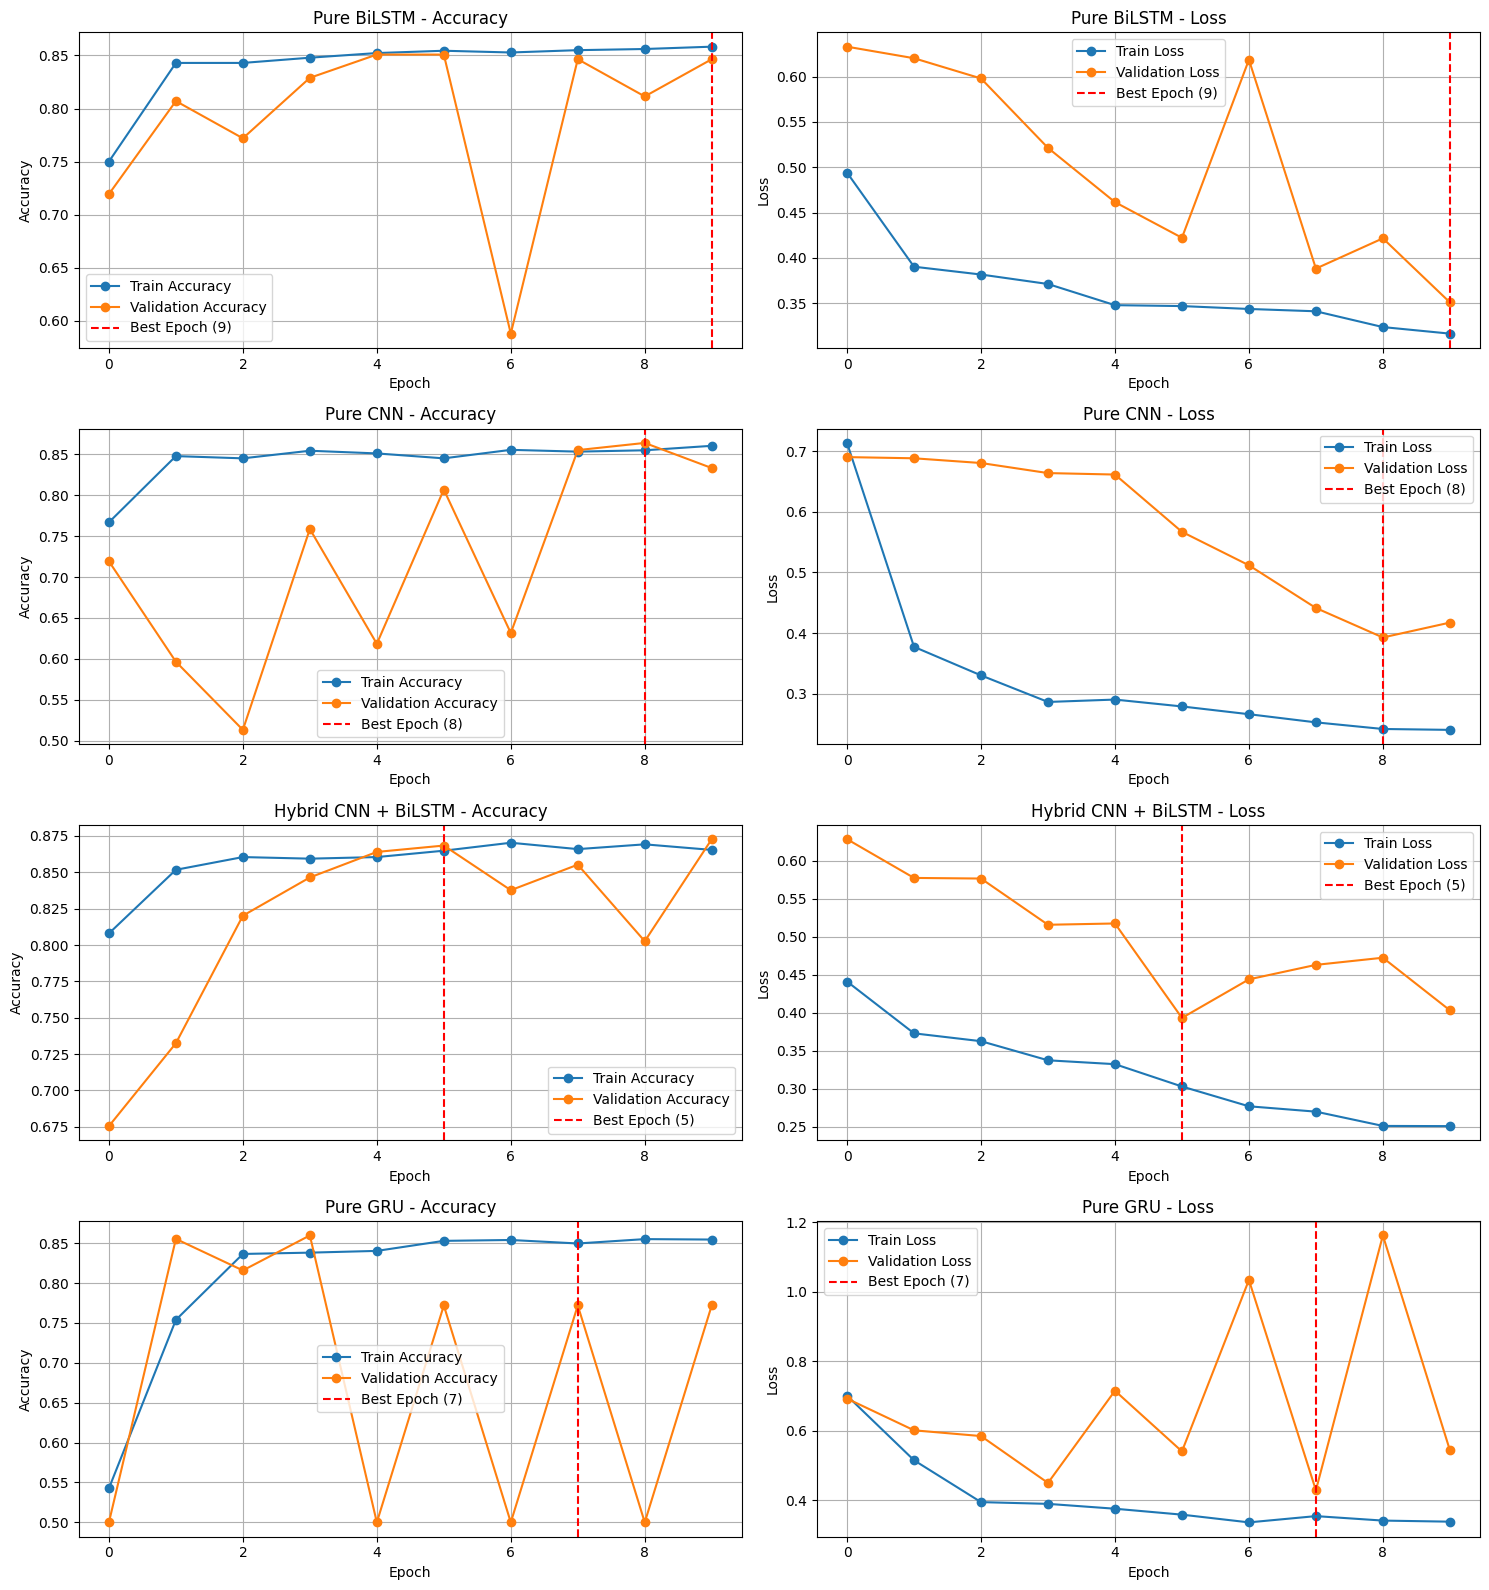

In [11]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 16))

# Menghitung best epoch (epoch dengan val_loss terendah) untuk masing-masing model
best_epoch_bilstm = np.argmin(history_bilstm.history['val_loss'])
best_epoch_cnn = np.argmin(history_cnn.history['val_loss'])
best_epoch_hybrid = np.argmin(history_hybrid.history['val_loss'])
best_epoch_gru = np.argmin(history_gru.history['val_loss'])

# --- 1. Pure BiLSTM ---
# Accuracy
plt.subplot(4, 2, 1)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_bilstm, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_bilstm})')
plt.title('Pure BiLSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(4, 2, 2)
plt.plot(history_bilstm.history['loss'], label='Train Loss', marker='o')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_bilstm, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_bilstm})')
plt.title('Pure BiLSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 2. Pure CNN ---
# Accuracy
plt.subplot(4, 2, 3)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_cnn, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_cnn})')
plt.title('Pure CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(4, 2, 4)
plt.plot(history_cnn.history['loss'], label='Train Loss', marker='o')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_cnn, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_cnn})')
plt.title('Pure CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 3. Hybrid CNN + BiLSTM ---
# Accuracy
plt.subplot(4, 2, 5)
plt.plot(history_hybrid.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_hybrid.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_hybrid, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_hybrid})')
plt.title('Hybrid CNN + BiLSTM - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(4, 2, 6)
plt.plot(history_hybrid.history['loss'], label='Train Loss', marker='o')
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_hybrid, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_hybrid})')
plt.title('Hybrid CNN + BiLSTM - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- 4. Pure GRU ---
# Accuracy
plt.subplot(4, 2, 7)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_gru, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_gru})')
plt.title('Pure GRU - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(4, 2, 8)
plt.plot(history_gru.history['loss'], label='Train Loss', marker='o')
plt.plot(history_gru.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_gru, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_gru})')
plt.title('Pure GRU - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
import shutil
import os

# Path file dari ModelCheckpoint di local runtime
source_bilstm = 'best_model_pure_bilstm.keras'
source_cnn = 'best_model_pure_cnn.keras'
source_hybrid = 'best_model_hybrid_cnn_lstm.keras'
source_gru = 'best_model_pure_gru.keras'

# Path tujuan di Google Drive
drive_dir = '/content/drive/My Drive/Digital Forensik/'
drive_bilstm = os.path.join(drive_dir, 'best_model_pure_bilstm.keras')
drive_cnn = os.path.join(drive_dir, 'best_model_pure_cnn.keras')
drive_hybrid = os.path.join(drive_dir, 'best_model_hybrid_cnn_lstm.keras')
drive_gru = os.path.join(drive_dir, 'best_model_pure_gru.keras')

# Memastikan folder tujuan ada
os.makedirs(drive_dir, exist_ok=True)

# 1. Save Pure BiLSTM
if os.path.exists(source_bilstm):
    shutil.copy2(source_bilstm, drive_bilstm)
    print(f"✅ Model Pure BiLSTM berhasil disimpan ke: {drive_bilstm}")
else:
    model_bilstm.save(drive_bilstm)
    print(f"✅ Model Pure BiLSTM (dari memori) berhasil disimpan ke: {drive_bilstm}")

# 2. Save Pure CNN
if os.path.exists(source_cnn):
    shutil.copy2(source_cnn, drive_cnn)
    print(f"✅ Model Pure CNN berhasil disimpan ke: {drive_cnn}")
else:
    model_cnn.save(drive_cnn)
    print(f"✅ Model Pure CNN (dari memori) berhasil disimpan ke: {drive_cnn}")

# 3. Save Hybrid CNN+BiLSTM
if os.path.exists(source_hybrid):
    shutil.copy2(source_hybrid, drive_hybrid)
    print(f"✅ Model Hybrid CNN+BiLSTM berhasil disimpan ke: {drive_hybrid}")
else:
    model_hybrid.save(drive_hybrid)
    print(f"✅ Model Hybrid CNN+BiLSTM (dari memori) berhasil disimpan ke: {drive_hybrid}")

# 4. Save Pure GRU
if os.path.exists(source_gru):
    shutil.copy2(source_gru, drive_gru)
    print(f"✅ Model Pure GRU berhasil disimpan ke: {drive_gru}")
else:
    model_gru.save(drive_gru)
    print(f"✅ Model Pure GRU (dari memori) berhasil disimpan ke: {drive_gru}")

✅ Model Pure BiLSTM berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_pure_bilstm.keras
✅ Model Pure CNN berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_pure_cnn.keras
✅ Model Hybrid CNN+BiLSTM berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_hybrid_cnn_lstm.keras
✅ Model Pure GRU berhasil disimpan ke: /content/drive/My Drive/Digital Forensik/best_model_pure_gru.keras


### 3. Test Data & Model LSTM


Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 460ms/step

=== HASIL EVALUASI ===
Akurasi Test: 85.65%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.78      0.99      0.87       115
Modified (1)       0.99      0.72      0.83       115

    accuracy                           0.86       230
   macro avg       0.88      0.86      0.85       230
weighted avg       0.88      0.86      0.85       230



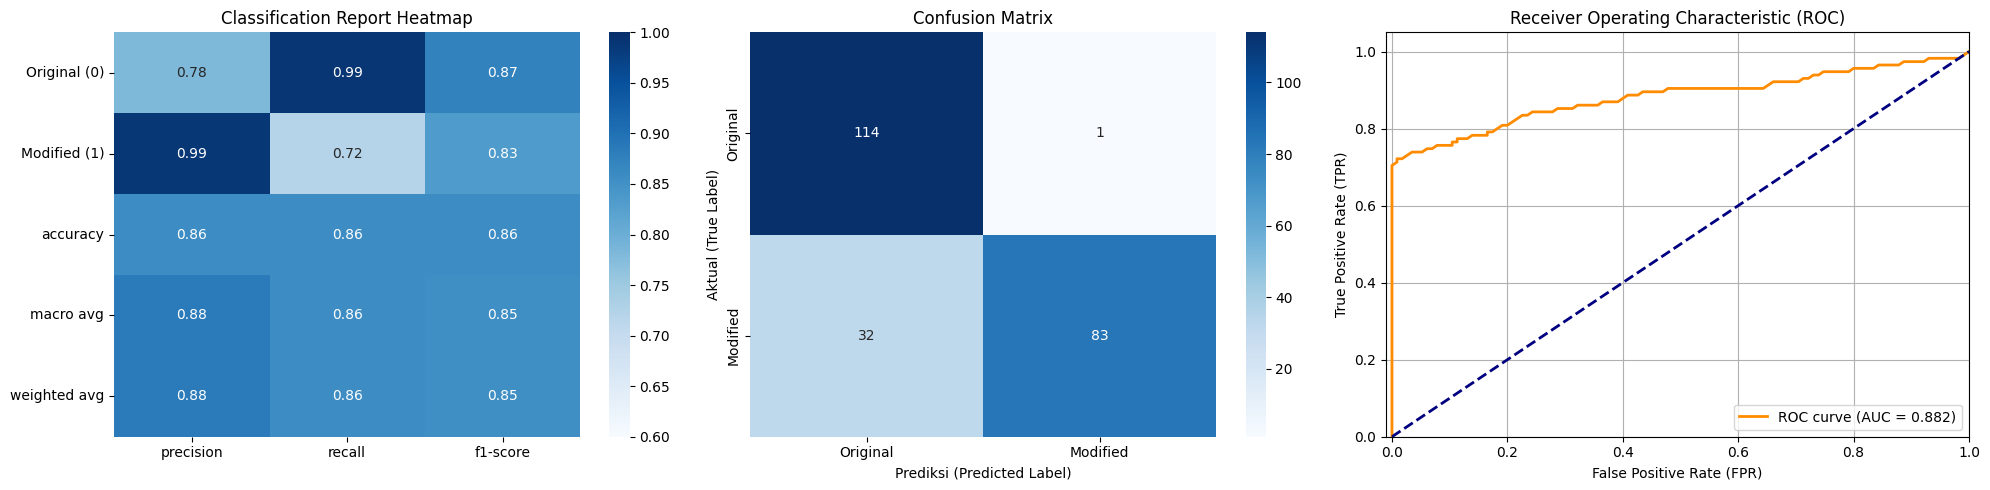

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_bilstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Evaluasi (Classification Report, Confusion Matrix & ROC Curve)
plt.figure(figsize=(20, 5))

# Plot Classification Report
plt.subplot(1, 3, 1)
report_dict = classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', cbar=True, vmin=0.6, vmax=1.0)
plt.title('Classification Report Heatmap')

# Plot Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

=== HASIL EVALUASI ===
Akurasi Test: 84.35%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.80      0.92      0.85       115
Modified (1)       0.91      0.77      0.83       115

    accuracy                           0.84       230
   macro avg       0.85      0.84      0.84       230
weighted avg       0.85      0.84      0.84       230



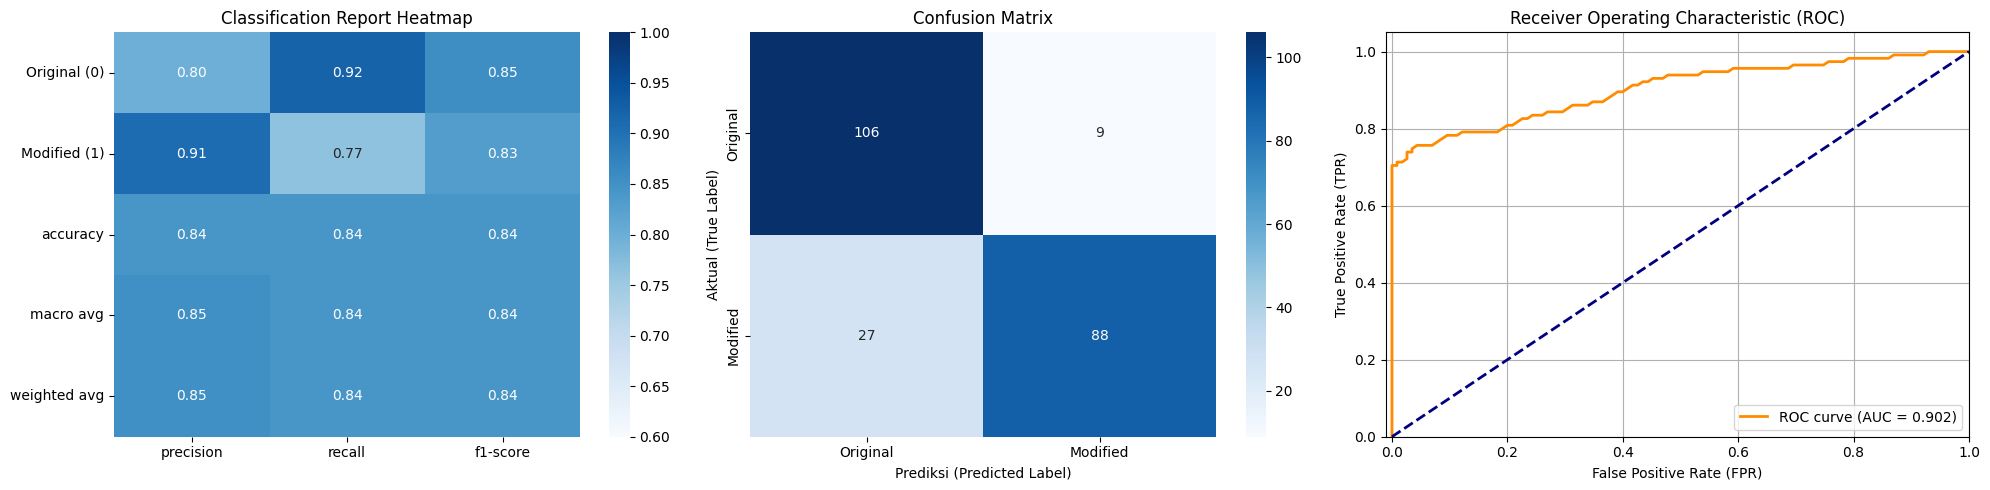

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_cnn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Evaluasi (Classification Report, Confusion Matrix & ROC Curve)
plt.figure(figsize=(20, 5))

# Plot Classification Report
plt.subplot(1, 3, 1)
report_dict = classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', cbar=True, vmin=0.6, vmax=1.0)
plt.title('Classification Report Heatmap')

# Plot Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step

=== HASIL EVALUASI ===
Akurasi Test: 86.52%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.80      0.97      0.88       115
Modified (1)       0.97      0.76      0.85       115

    accuracy                           0.87       230
   macro avg       0.88      0.87      0.86       230
weighted avg       0.88      0.87      0.86       230



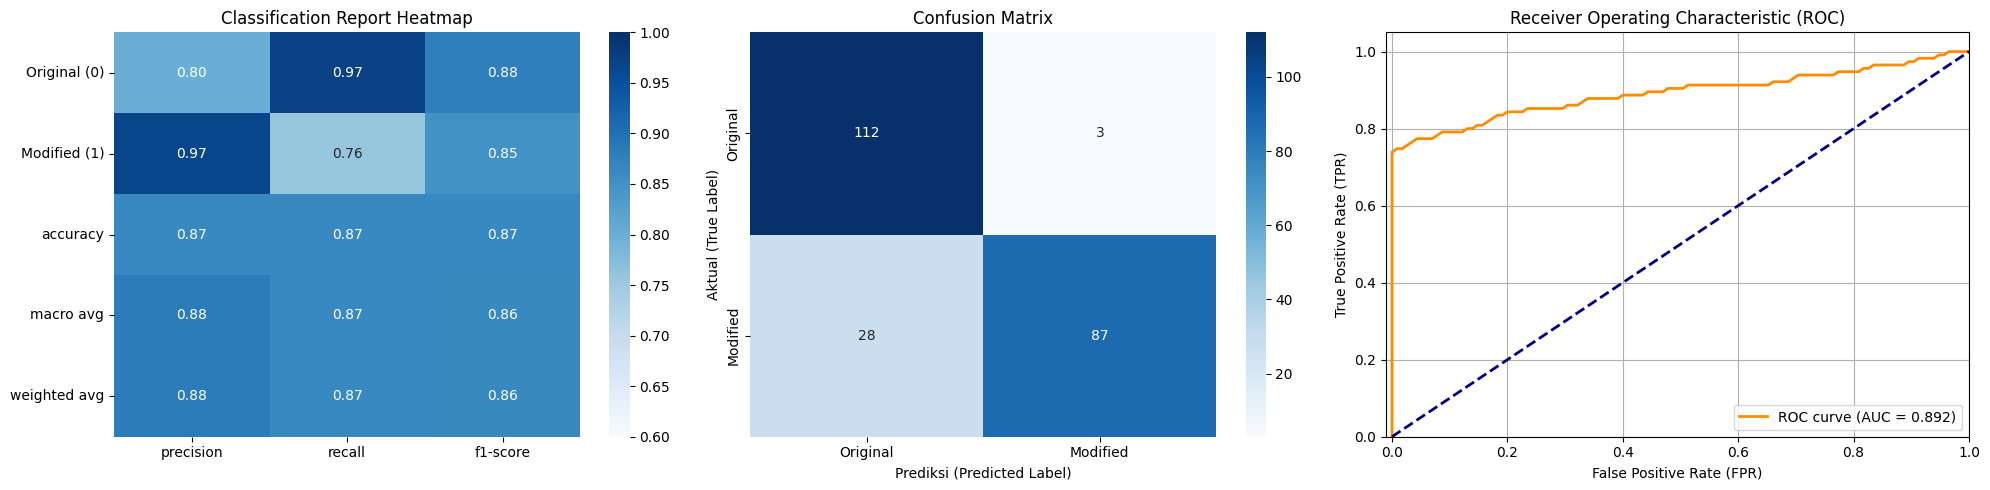

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_hybrid.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Evaluasi (Classification Report, Confusion Matrix & ROC Curve)
plt.figure(figsize=(20, 5))

# Plot Classification Report
plt.subplot(1, 3, 1)
report_dict = classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', cbar=True, vmin=0.6, vmax=1.0)
plt.title('Classification Report Heatmap')

# Plot Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


Memulai prediksi pada data test...
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 467ms/step

=== HASIL EVALUASI ===
Akurasi Test: 76.09%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.68      1.00      0.81       115
Modified (1)       1.00      0.52      0.69       115

    accuracy                           0.76       230
   macro avg       0.84      0.76      0.75       230
weighted avg       0.84      0.76      0.75       230



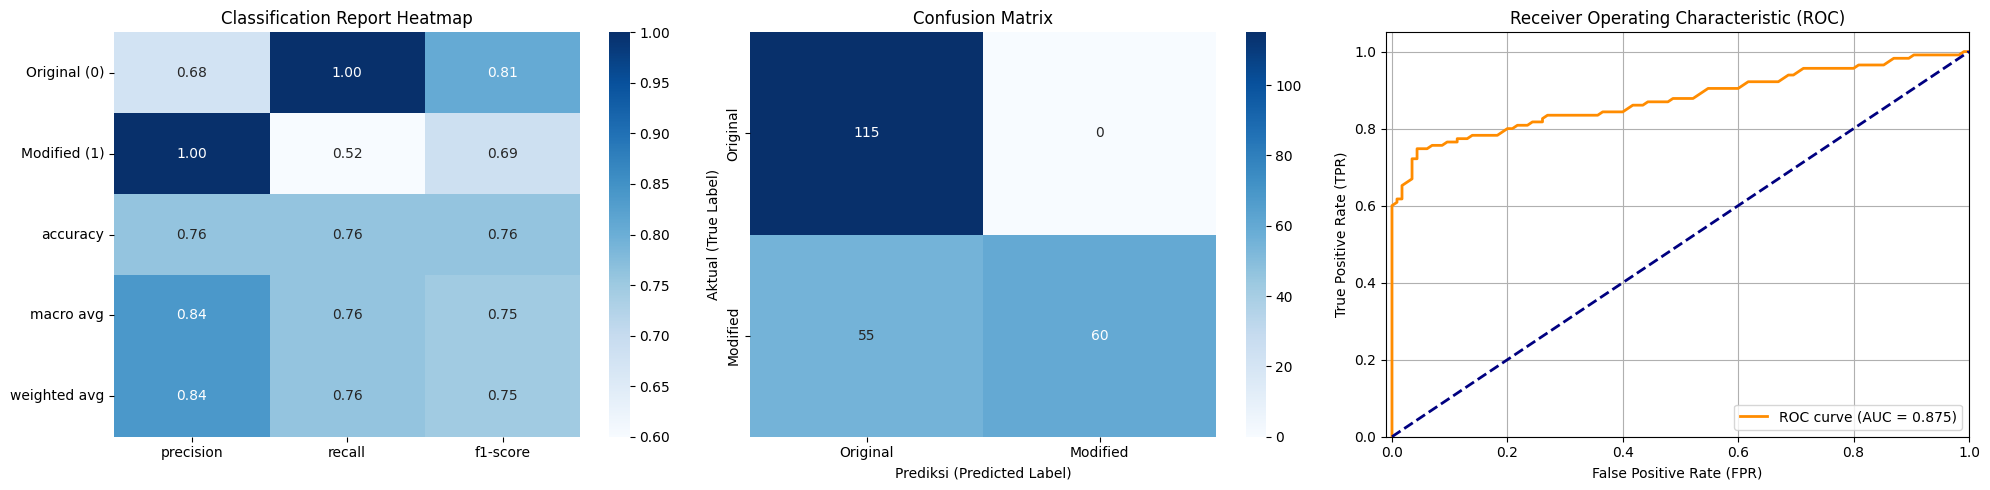

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test...")
# 1. Lakukan Prediksi
y_pred_prob = model_gru.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n=== HASIL EVALUASI ===")
print(f"Akurasi Test: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Evaluasi (Classification Report, Confusion Matrix & ROC Curve)
plt.figure(figsize=(20, 5))

# Plot Classification Report
plt.subplot(1, 3, 1)
report_dict = classification_report(y_test, y_pred, target_names=['Original (0)', 'Modified (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T
sns.heatmap(report_df, annot=True, cmap='Blues', fmt='.2f', cbar=True, vmin=0.6, vmax=1.0)
plt.title('Classification Report Heatmap')

# Plot Confusion Matrix
plt.subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 3, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


### Menampilkan Tingkat Keyakinan (Confidence) Prediksi

In [16]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_bilstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 458ms/step
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
70,53_RPS.pdf,original,original,0.220335,77.966510
123,328_edaran_metadataEdit.pdf,modified,original,0.144956,85.504441
227,257_edaran_print.pdf,modified,modified,0.997942,99.794155
76,912_transkrips.pdf,original,original,0.346778,65.322161
112,232_edaran.pdf,original,original,0.145111,85.488883
208,1073_otherUniv_print.pdf,modified,modified,0.998247,99.824691
164,667_undangan_editContent.pdf,modified,modified,0.999681,99.968135
51,766_sertifikat.pdf,original,original,0.102492,89.750793
199,987_transkrips_metadataEdit.pdf,modified,original,0.137842,86.215818
194,933_transkrips_print.pdf,modified,modified,0.993389,99.338901


In [19]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_cnn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
108,245_edaran.pdf,original,original,0.360033,63.996685
84,968_transkrips.pdf,original,original,0.292652,70.734769
181,57_RPS_print.pdf,modified,modified,0.986541,98.654139
180,53_RPS_print.pdf,modified,modified,0.977436,97.743553
207,1069_otherUniv_print.pdf,modified,modified,0.982144,98.214430
43,637_undangan.pdf,original,original,0.286099,71.390066
48,775_sertifikat.pdf,original,original,0.412760,58.724004
69,84_RPS.pdf,original,modified,0.503034,50.303406
56,514_pemberitahuan.pdf,original,original,0.387452,61.254752
61,836_RPS.pdf,original,original,0.148254,85.174595


In [21]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_hybrid.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
28,494_edaran.pdf,original,original,0.404732,59.526762
121,309_edaran_print.pdf,modified,modified,0.975115,97.511542
224,234_edaran_print.pdf,modified,modified,0.970951,97.095054
134,417_edaran_metadataEdit.pdf,modified,original,0.419963,58.003688
67,13_RPS.pdf,original,original,0.273980,72.601980
98,1097_otherUniv.pdf,original,original,0.432685,56.731507
223,232_edaran_print.pdf,modified,modified,0.970465,97.046453
23,447_edaran.pdf,original,original,0.392150,60.784969
106,352_edaran.pdf,original,original,0.429003,57.099745
228,260_edaran_print.pdf,modified,modified,0.975403,97.540343


In [22]:
import pandas as pd

# Lakukan Prediksi
y_pred_prob = model_gru.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Membuat DataFrame untuk melihat hasil prediksi beserta probabilitasnya di data test
results_df = pd.DataFrame({
    'Filename': test_df['filename'],
    'Actual Label': test_df['label'],
    'Predicted Label': ['modified' if p == 1 else 'original' for p in y_pred],
    'Probabilitas Modified': y_pred_prob.flatten(),
})

# Menghitung Persentase Keyakinan (Confidence)
# Jika probabilitas >= 0.5, confidence = probabilitas
# Jika probabilitas < 0.5, confidence = 1 - probabilitas
results_df['Confidence (%)'] = results_df['Probabilitas Modified'].apply(
    lambda x: (x if x >= 0.5 else 1 - x) * 100
)

print("=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===")
display(results_df.sample(10))

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 468ms/step
=== CONTOH TINGKAT KEYAKINAN PREDIKSI MODEL PADA DATA TEST ===


,Filename,Actual Label,Predicted Label,Probabilitas Modified,Confidence (%)
14,446_edaran.pdf,original,original,0.168537,83.146332
160,637_undangan_print.pdf,modified,modified,0.934031,93.403065
132,403_edaran_metadataEdit.pdf,modified,original,0.234957,76.504284
5,450_edaran.pdf,original,original,0.220004,77.999648
51,766_sertifikat.pdf,original,original,0.288443,71.155697
70,53_RPS.pdf,original,original,0.171989,82.801093
44,616_undangan.pdf,original,original,0.215942,78.405811
29,309_edaran.pdf,original,original,0.182075,81.792510
204,1051_otherUniv_compressed.pdf,modified,original,0.345374,65.462634
159,625_undangan_print.pdf,modified,modified,0.855208,85.520750


### Cek Jenis PDF (Scan vs Born-Digital)
Fungsi di bawah ini menggunakan `pymupdf` untuk mendeteksi apakah suatu dokumen PDF merupakan dokumen murni (born-digital) atau hasil scan, berdasarkan keberadaan teks di dalamnya.

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 78.0 MB/s eta 0:00:00


In [ ]:
import pymupdf
import os

def check_pdf_scan_or_digital(file_path):
    """Mengecek apakah PDF berupa hasil scan atau born-digital."""
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return

    print(f"Mengecek dokumen: {os.path.basename(file_path)}")
    try:
        doc = pymupdf.open(file_path)

        for i, page in enumerate(doc):
            text = page.get_text("text").strip()

            if len(text) == 0:
                print(f"  Halaman {i+1}: Kemungkinan scan (tidak ada teks terdeteksi)")
            else:
                print(f"  Halaman {i+1}: Kemungkinan born-digital (teks terdeteksi)")

        doc.close()
    except Exception as e:
        print(f"Error saat membaca file: {e}")


### Fungsi untuk Verifikasi Dokumen Baru


In [ ]:
def verify_document(file_path, model, max_len=MAX_BYTE_LEN):
    """Fungsi untuk memverifikasi satu dokumen PDF dan mengembalikan persentase keyakinan."""
    if not os.path.exists(file_path):
        print(f"File tidak ditemukan: {file_path}")
        return

    # 1. Baca byte stream dari file
    with open(file_path, "rb") as f:
        bytes_content = list(f.read(max_len))

    # 2. Lakukan padding sesuai ukuran input model
    X_input = pad_sequences([bytes_content], maxlen=max_len, padding="post", truncating="post", value=0)

    # 3. Lakukan prediksi (mendapatkan nilai probabilitas)
    prob = model_bilstm.predict(X_input, verbose=0)[0][0]

    # 4. Tentukan hasil berdasarkan probabilitas
    if prob >= 0.5:
        status = "MODIFIED (Telah Dimodifikasi)"
        confidence = prob * 100
    else:
        status = "ORIGINAL (Asli)"
        confidence = (1 - prob) * 100

    print("="*50)
    print(f"📄 File yang diuji  : {os.path.basename(file_path)}")
    print(f"🔍 Hasil Verifikasi : {status}")
    print(f"📈 Tingkat Keyakinan: {confidence:.2f}%")
    print("="*50)

# --- Contoh Penggunaan ---

print("Menguji Fungsi Verifikasi:\n")
sample_ori = test_df[test_df['label'] == 'original'].iloc[0]['full_path']
sample_mod = test_df[test_df['label'] == 'modified'].iloc[0]['full_path']

verify_document(sample_ori, model_bilstm)
check_pdf_scan_or_digital(sample_ori)
verify_document(sample_mod, model_bilstm)
check_pdf_scan_or_digital(sample_mod)

Menguji Fungsi Verifikasi:

📄 File yang diuji  : 259_edaran.pdf
🔍 Hasil Verifikasi : ORIGINAL (Asli)
📈 Tingkat Keyakinan: 84.18%
Mengecek dokumen: 259_edaran.pdf
  Halaman 1: Kemungkinan born-digital (teks terdeteksi)
  Halaman 2: Kemungkinan born-digital (teks terdeteksi)
  Halaman 3: Kemungkinan born-digital (teks terdeteksi)
  Halaman 4: Kemungkinan born-digital (teks terdeteksi)
  Halaman 5: Kemungkinan born-digital (teks terdeteksi)
  Halaman 6: Kemungkinan born-digital (teks terdeteksi)
  Halaman 7: Kemungkinan born-digital (teks terdeteksi)
  Halaman 8: Kemungkinan born-digital (teks terdeteksi)
  Halaman 9: Kemungkinan born-digital (teks terdeteksi)
  Halaman 10: Kemungkinan born-digital (teks terdeteksi)
📄 File yang diuji  : 272_edaran_print.pdf
🔍 Hasil Verifikasi : MODIFIED (Telah Dimodifikasi)
📈 Tingkat Keyakinan: 99.95%
Mengecek dokumen: 272_edaran_print.pdf
  Halaman 1: Kemungkinan born-digital (teks terdeteksi)


### 4. Training Model - Versi Chunk Based
Pada pendekatan ini, daripada membaca file sebagai satu sekuens panjang (misal 10.000 byte), kita akan memecahnya menjadi beberapa *chunk* (misal per 1000 byte). Masing-masing chunk dari sebuah file akan diberi label yang sama dengan file aslinya.

In [ ]:
import numpy as np
import os
import tensorflow as tf

CHUNK_SIZE = 1000
MAX_CHUNKS_PER_FILE = 20  # Maksimal 20 chunk per file (total representasi 10.000 byte)

def prepare_data_chunked(df, chunk_size=CHUNK_SIZE, max_chunks=MAX_CHUNKS_PER_FILE):
    X_chunked, y_chunked = [], []
    for _, row in df.iterrows():
        path = row["full_path"]
        label = 1 if row["label"] == "modified" else 0
        if os.path.exists(path):
            try:
                with open(path, "rb") as f:
                    # Baca byte sesuai batas maksimal yang ingin kita olah
                    bytes_content = f.read(chunk_size * max_chunks)

                    # Pecah menjadi beberapa chunk
                    for i in range(0, len(bytes_content), chunk_size):
                        chunk = list(bytes_content[i:i+chunk_size])
                        # Lakukan padding pada chunk terakhir jika kurang dari chunk_size
                        if len(chunk) < chunk_size:
                            chunk = chunk + [0] * (chunk_size - len(chunk))

                        X_chunked.append(chunk)
                        y_chunked.append(label)
            except Exception as e:
                pass

    return np.array(X_chunked), np.array(y_chunked)

print("Mengekstrak dan memecah data menjadi chunk...")
X_train_chunk, y_train_chunk = prepare_data_chunked(train_df)
X_val_chunk, y_val_chunk = prepare_data_chunked(val_df)
X_test_chunk, y_test_chunk = prepare_data_chunked(test_df)

print(f"X_train_chunk shape: {X_train_chunk.shape}, y_train_chunk shape: {y_train_chunk.shape}")
print(f"X_val_chunk shape: {X_val_chunk.shape}, y_val_chunk shape: {y_val_chunk.shape}")

Mengekstrak dan memecah data menjadi chunk...


Test Chunk Data: 100%|██████████| 230/230 [00:00<00:00, 852.94it/s]


X_train_chunk shape: (18266, 1000), y_train_chunk shape: (18266,)
X_val_chunk shape: (2280, 1000), y_val_chunk shape: (2280,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Bidirectional, GRU, Dropout, BatchNormalization, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Membangun Model untuk Chunk-Based
# Karena sequence length lebih pendek (1000 vs 10000), komputasi per langkah akan lebih ringan

model_chunk = Sequential([
    Input(shape=(CHUNK_SIZE,)),
    Embedding(input_dim=257, output_dim=64),

    # CNN untuk ekstraksi pola byte lokal di dalam chunk
    Conv1D(filters=32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=4),

    # BiGRU untuk sequence learning di dalam chunk
    Bidirectional(GRU(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(GRU(32)),

    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_chunk.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model_chunk.summary()

callbacks_chunk = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model_chunk.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("\nMemulai training model versi Chunk-Based...")
history_chunk = model_chunk.fit(
    X_train_chunk, y_train_chunk,
    epochs=20,
    batch_size=64, # Batch size bisa lebih besar karena dimensi sequence lebih kecil
    validation_data=(X_val_chunk, y_val_chunk),
    callbacks=callbacks_chunk
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 1000, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 996, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 249, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 249, 128)       │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 249, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,825 (382.13 KB)

 Trainable params: 97,697 (381.63 KB)

 Non-trainable params: 128 (512.00 B)


Memulai training model versi Chunk-Based...
Epoch 1/20
286/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5693 - loss: 0.6683
Epoch 1: val_loss improved from None to 0.67392, saving model to best_model_chunk.keras

Epoch 1: finished saving model to best_model_chunk.keras
286/286 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6080 - loss: 0.6435 - val_accuracy: 0.5825 - val_loss: 0.6739 - learning_rate: 0.0010
Epoch 2/20
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6971 - loss: 0.5742
Epoch 2: val_loss did not improve from 0.67392
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6932 - loss: 0.5782 - val_accuracy: 0.5009 - val_loss: 0.8323 - learning_rate: 0.0010
Epoch 3/20
285/286 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7462 - loss: 0.5251
Epoch 3: val_loss did not improve from 0.67392
286/286 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.7415 - loss: 0.5310 - val_accuracy: 0.5241 - val_loss: 0.9926 - learning_rate: 0.0010
Epoch 4/20
285/286 ━━━━━━

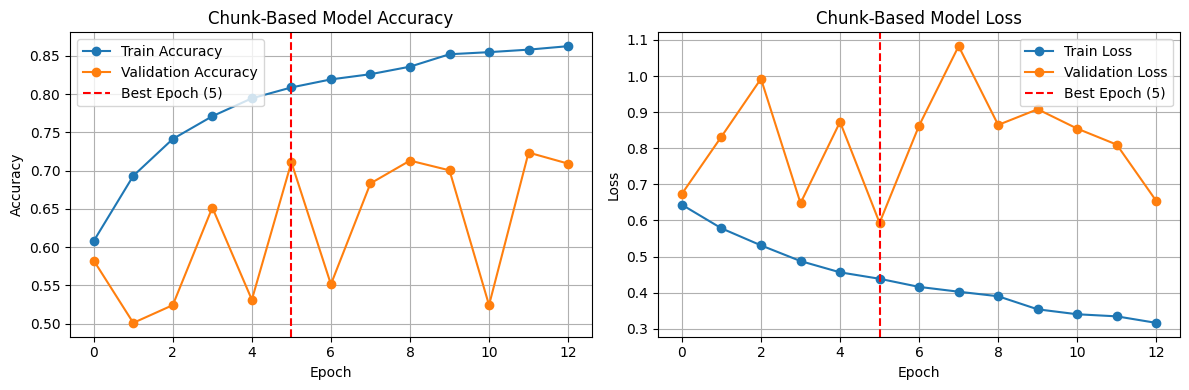

In [ ]:
# Visualisasi Hasil Training Model Chunk-Based
best_epoch_chunk = np.argmin(history_chunk.history['val_loss'])
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history_chunk.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_chunk.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.axvline(x=best_epoch_chunk, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_chunk})')
plt.title('Chunk-Based Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_chunk.history['loss'], label='Train Loss', marker='o')
plt.plot(history_chunk.history['val_loss'], label='Validation Loss', marker='o')
plt.axvline(x=best_epoch_chunk, color='r', linestyle='--', label=f'Best Epoch ({best_epoch_chunk})')
plt.title('Chunk-Based Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 5. Evaluasi Model Chunk-Based
Mari kita uji performa model chunk-based menggunakan data test yang telah dipecah menjadi chunk.

Memulai prediksi pada data test (Chunk-Based)...
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

=== HASIL EVALUASI (CHUNK-BASED) ===
Akurasi Test: 72.48%

Classification Report:
              precision    recall  f1-score   support

Original (0)       0.70      0.78      0.74      1150
Modified (1)       0.75      0.67      0.71      1150

    accuracy                           0.72      2300
   macro avg       0.73      0.72      0.72      2300
weighted avg       0.73      0.72      0.72      2300



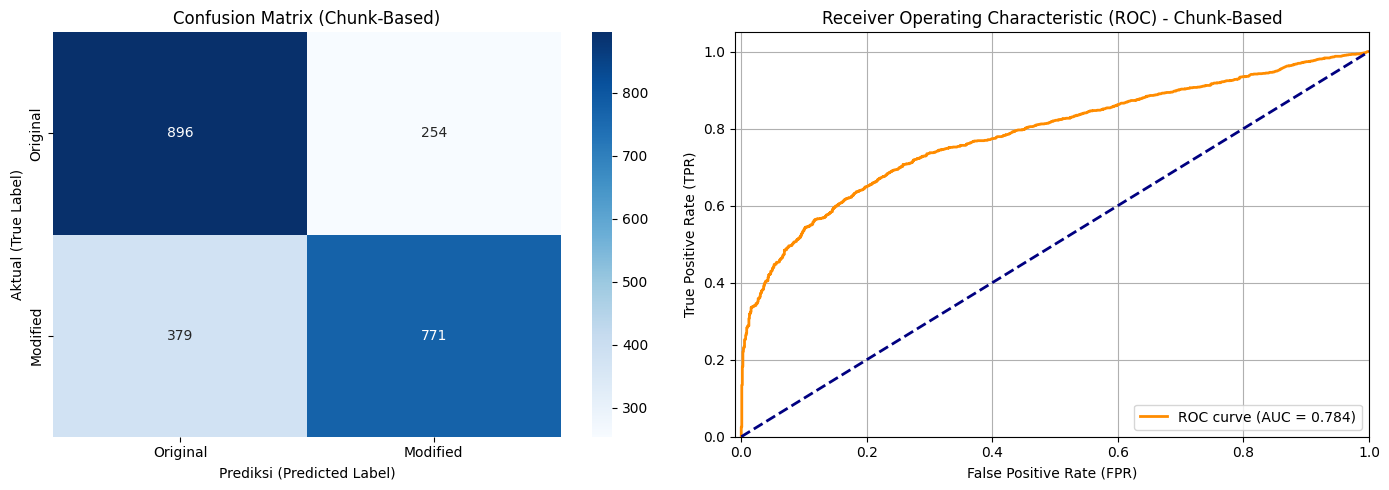

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

print("Memulai prediksi pada data test (Chunk-Based)...")
# 1. Lakukan Prediksi
y_pred_prob_chunk = model_chunk.predict(X_test_chunk)
y_pred_chunk = (y_pred_prob_chunk > 0.5).astype(int).flatten()

# 2. Metrik Evaluasi
acc_chunk = accuracy_score(y_test_chunk, y_pred_chunk)
print(f"\n=== HASIL EVALUASI (CHUNK-BASED) ===")
print(f"Akurasi Test: {acc_chunk * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test_chunk, y_pred_chunk, target_names=['Original (0)', 'Modified (1)']))

# 3. Visualisasi Evaluasi (Classification Report, Confusion Matrix & ROC Curve)
plt.figure(figsize=(20, 5))

# Plot Classification Report
plt.subplot(1, 3, 1)
report_dict_chunk = classification_report(y_test_chunk, y_pred_chunk, target_names=['Original (0)', 'Modified (1)'], output_dict=True)
report_df_chunk = pd.DataFrame(report_dict_chunk).iloc[:-1, :].T
sns.heatmap(report_df_chunk, annot=True, cmap='Blues', fmt='.2f', cbar=True, vmin=0.5, vmax=1.0)
plt.title('Classification Report Heatmap (Chunk-Based)')

# Plot Confusion Matrix
plt.subplot(1, 3, 2)
cm_chunk = confusion_matrix(y_test_chunk, y_pred_chunk)
sns.heatmap(cm_chunk, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original', 'Modified'],
            yticklabels=['Original', 'Modified'])
plt.title('Confusion Matrix (Chunk-Based)')
plt.xlabel('Prediksi (Predicted Label)')
plt.ylabel('Aktual (True Label)')

# Plot ROC Curve
plt.subplot(1, 3, 3)
fpr_chunk, tpr_chunk, thresholds_chunk = roc_curve(y_test_chunk, y_pred_prob_chunk)
roc_auc_chunk = auc(fpr_chunk, tpr_chunk)

plt.plot(fpr_chunk, tpr_chunk, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_chunk:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Chunk-Based')
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()


### Contoh Ekstraksi Byte dari Satu Dokumen PDF dan Perhitungan Nilai Entropy

In [ ]:
import os

sample_file_path = test_df[test_df['label'] == 'original'].iloc[0]['full_path']

print(f"Mengekstrak byte dari file: {os.path.basename(sample_file_path)}")

try:
    with open(sample_file_path, "rb") as f:
        bytes_content = list(f.read(200))

    print(f"Total byte yang dibaca: {len(bytes_content)}")
    print("\n--- 200 Byte Pertama ---")
    print(bytes_content[:200])

except Exception as e:
    print(f"Gagal membaca file {sample_file_path}: {e}")

Mengekstrak byte dari file: 259_edaran.pdf
Total byte yang dibaca: 200

--- 200 Byte Pertama ---
[37, 80, 68, 70, 45, 49, 46, 51, 10, 37, 196, 229, 242, 229, 235, 167, 243, 160, 208, 196, 198, 10, 51, 32, 48, 32, 111, 98, 106, 10, 60, 60, 32, 47, 70, 105, 108, 116, 101, 114, 32, 47, 70, 108, 97, 116, 101, 68, 101, 99, 111, 100, 101, 32, 47, 76, 101, 110, 103, 116, 104, 32, 53, 56, 53, 54, 32, 62, 62, 10, 115, 116, 114, 101, 97, 109, 10, 120, 1, 189, 157, 91, 115, 220, 200, 117, 199, 223, 241, 41, 144, 183, 97, 202, 130, 6, 215, 25, 56, 91, 91, 225, 138, 27, 89, 90, 75, 150, 37, 42, 46, 87, 156, 74, 173, 164, 93, 73, 166, 69, 209, 75, 179, 236, 228, 211, 251, 119, 186, 207, 193, 165, 209, 192, 128, 228, 48, 47, 26, 98, 6, 56, 221, 231, 246, 63, 151, 238, 134, 254, 154, 62, 126, 149, 126, 243, 77, 250, 248, 197, 147, 103, 103, 233, 54, 253, 246, 219, 244, 187, 179, 39, 233, 239, 211, 191, 114, 177, 205, 182, 219, 109, 217, 52, 69, 158, 214, 109, 157, 85, 85, 186, 175, 242, 172, 205, 219,

Menganalisis Entropi dari 10 dokumen...



,Filename,Label,Entropi (Byte List),Entropi (Char Token),Selisih
0,157_edaran_compressed.pdf,modified,7.9336,4.3633,3.5703
1,28_RPS.pdf,original,7.1223,4.0342,3.0880
2,341_edaran.pdf,original,7.2143,4.6348,2.5795
3,920_transkrips_compressed.pdf,modified,7.9712,4.3217,3.6495
4,425_edaran.pdf,original,7.8476,4.4282,3.4194
5,987_transkrips_metadataEdit.pdf,modified,7.6763,4.5604,3.1159
6,413_edaran.pdf,original,7.8446,4.4398,3.4048
7,943_transkrips_print.pdf,modified,7.9130,4.3580,3.5550
8,571_pemberitahuan_editContent.pdf,modified,6.9945,4.3726,2.6219
9,356_edaran_metadataEdit.pdf,modified,7.7616,4.5354,3.2261



CATATAN:
- Entropi (Byte List): Dihitung dari list murni nilai byte integer 0-255.
- Entropi (Char Token): Dihitung dari konversi representasi string (termasuk karakter 'b', '\x', dll).
- Metode Char Token umumnya menghasilkan entropi yang lebih rendah secara konsisten pada file PDF karena representasi string mengubah byte non-printable menjadi urutan karakter seperti '\x00', '\n', dll. Hal ini meningkatkan frekuensi karakter tertentu (seperti '\' dan 'x'), sehingga mengurangi tingkat keacakan/kompleksitas relatif terhadap panjang total sequence.




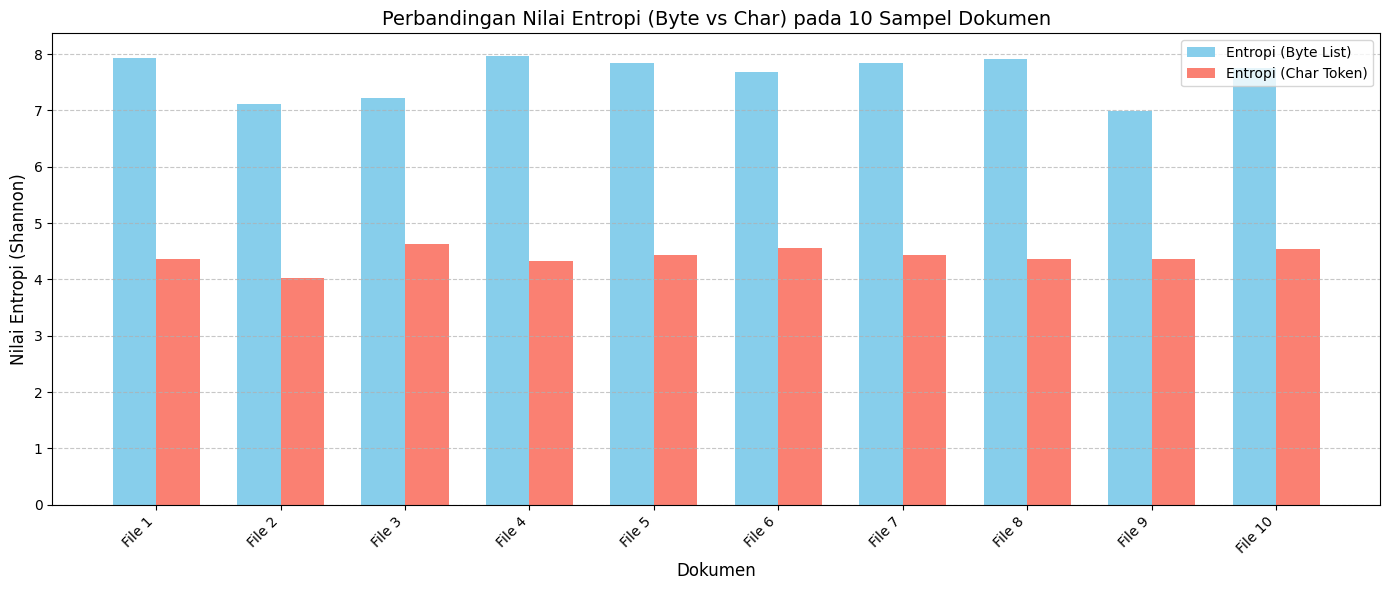

In [33]:
import os
import math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def calculate_entropy(data_sequence):
    """Menghitung Shannon Entropy dari sebuah sequence data."""
    if not data_sequence:
        return 0.0

    counts = Counter(data_sequence)
    total_len = len(data_sequence)

    entropy = 0.0
    for count in counts.values():
        p_x = count / total_len
        if p_x > 0:
            entropy -= p_x * math.log2(p_x)
    return entropy

# Ambil 10 sampel dokumen secara acak dari data test
sample_files = test_df.sample(10, random_state=42)
max_len = 10000

print("Menganalisis Entropi dari 10 dokumen...\n")

results = []

for idx, row in sample_files.iterrows():
    file_path = row['full_path']
    label = row['label']
    filename = row['filename']

    if os.path.exists(file_path):
        with open(file_path, "rb") as f:
            raw_bytes = f.read(max_len)

        # Metode 1: Ekstraksi Byte List (f.read langsung)
        byte_list = list(raw_bytes)
        entropy_byte = calculate_entropy(byte_list)

        # Metode 2: Ekstraksi Char-level Tokenization
        string_content = str(raw_bytes)
        char_tokens = [ord(char) for char in string_content]
        entropy_char = calculate_entropy(char_tokens)

        results.append({
            "Filename": filename,
            "Label": label,
            "Entropi (Byte List)": round(entropy_byte, 4),
            "Entropi (Char Token)": round(entropy_char, 4),
            "Selisih": round(entropy_byte - entropy_char, 4)
        })

# Tampilkan hasil dalam bentuk DataFrame agar rapi
df_entropy_results = pd.DataFrame(results)
display(df_entropy_results)

print("\nCATATAN:")
print("- Entropi (Byte List): Dihitung dari list murni nilai byte integer 0-255.")
print("- Entropi (Char Token): Dihitung dari konversi representasi string (termasuk karakter 'b', '\\x', dll).")
print("- Metode Char Token umumnya menghasilkan entropi yang lebih rendah secara konsisten pada file PDF karena representasi string mengubah byte non-printable menjadi urutan karakter seperti '\\x00', '\\n', dll. Hal ini meningkatkan frekuensi karakter tertentu (seperti '\\' dan 'x'), sehingga mengurangi tingkat keacakan/kompleksitas relatif terhadap panjang total sequence.")
print("\n")

# --- VISUALISASI PERBANDINGAN ENTROPI ---
plt.figure(figsize=(14, 6))
x = np.arange(len(df_entropy_results))
width = 0.35

plt.bar(x - width/2, df_entropy_results['Entropi (Byte List)'], width, label='Entropi (Byte List)', color='skyblue')
plt.bar(x + width/2, df_entropy_results['Entropi (Char Token)'], width, label='Entropi (Char Token)', color='salmon')

plt.title('Perbandingan Nilai Entropi (Byte vs Char) pada 10 Sampel Dokumen', fontsize=14)
plt.xlabel('Dokumen', fontsize=12)
plt.ylabel('Nilai Entropi (Shannon)', fontsize=12)

# Ubah label sumbu x menjadi File 1, File 2, dst
file_labels = [f'File {i+1}' for i in range(len(df_entropy_results))]
plt.xticks(x, file_labels, rotation=45, ha='right')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
